# MNase Length distribution computation

Create the length distributions curves from the sample and chromosome data. The chromosomes are to allow for debugging any anomalies in distribution. The end result is a target length distribution computed from the average replicate 1 and 2 length distributions. And plots that depict this normalization process and concordance between the replicates and individual samples.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [419]:
from src.length_distribution import LengthDistributionCalculator

length_dist_calculator1 = LengthDistributionCalculator(1)
length_counts, lengths_dists = length_dist_calculator1.load_distributions_for_chrom(1)
length_dist_calculator1.compute_length_distributions_for_all_chroms()
rep1_length_distribution = length_dist_calculator1.create_rep_distribution()

1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,00:02:30.523


In [420]:
length_dist_calculator2 = LengthDistributionCalculator(2)
length_counts, lengths_dists = length_dist_calculator2.load_distributions_for_chrom(2)
length_dist_calculator2.compute_length_distributions_for_all_chroms()
rep2_length_distribution = length_dist_calculator2.create_rep_distribution()

1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,00:02:42.576


In [421]:
combined_target_distribution = (rep1_length_distribution + rep2_length_distribution)/2.

In [453]:
target_distribution_df = pd.DataFrame({'combined': combined_target_distribution,
             'rep1': distribution_rep1,
             'rep2': distribution_rep2})
target_distribution_df.index.name = 'fragment_length'

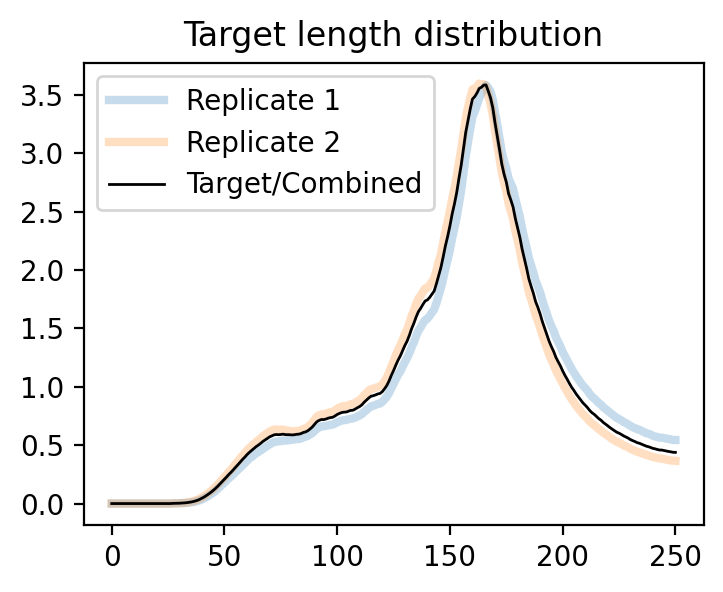

In [423]:
plt.figure(figsize=(4, 3))
plt.plot(target_distribution_df['rep1'], alpha=0.25, lw=3, label="Replicate 1")
plt.plot(target_distribution_df['rep2'], alpha=0.25, lw=3, label="Replicate 2")
plt.plot(target_distribution_df['combined'], c='black', lw=1, label="Target/Combined")
plt.title("Target length distribution")
plt.legend()

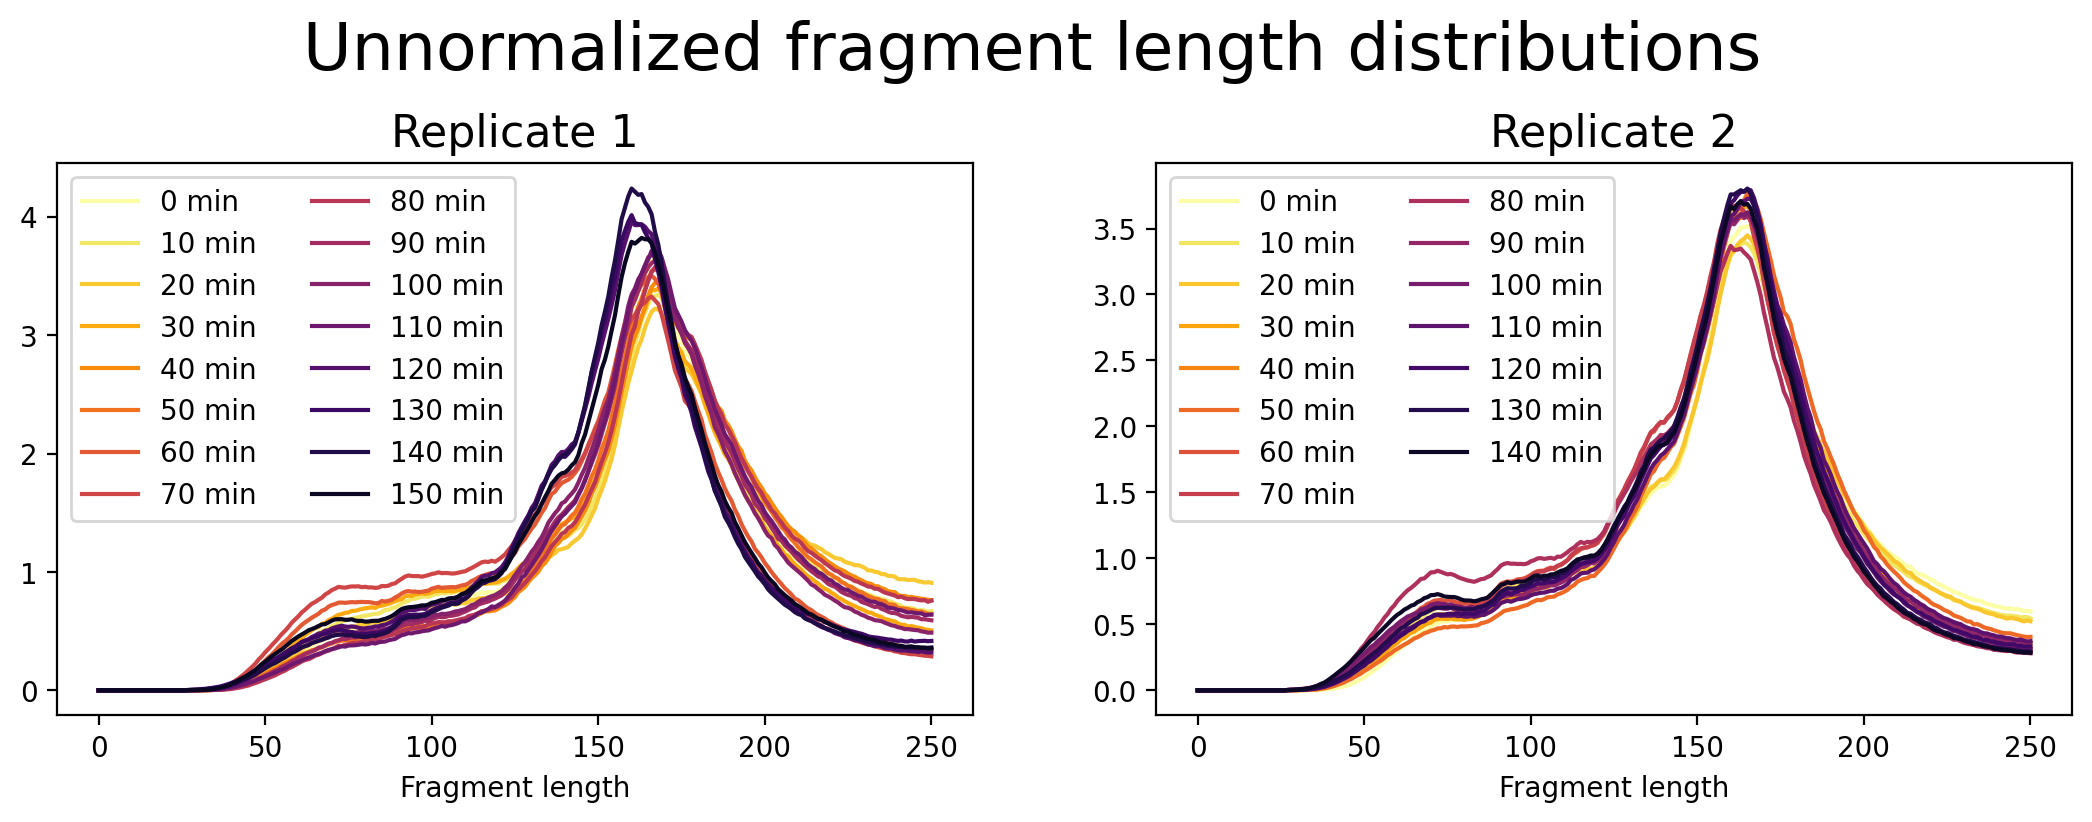

In [452]:
from src.length_distribution import plot_fragment_length_distributions

plot_fragment_length_distributions(length_dist_calculator1.all_length_dists, 
    length_dist_calculator2.all_length_dists)